This routine generates the **composite Figure 3** i.e a dominant-driver map and four stacked-area panels for the no-reuse baseline, followed by the same pair for full potable reuse.

## 1. Libraries

In [23]:
suppressPackageStartupMessages({
  library(arrow)
  library(dplyr)
  library(ggplot2)
  library(sf)
  library(gridExtra)
  library(grid)
})

# use_svglite <- requireNamespace("svglite", quietly = TRUE)
# if (!use_svglite) message("[INFO] svglite unavailable -- SVG output via base svg()")

## 2. Paths

Same YAML-based resolution as the other Figure 3 notebooks.

In [24]:
NB_DIR    <- normalizePath(getwd(), winslash = "/")
REPO_ROOT <- if (basename(NB_DIR) == "notebooks") dirname(NB_DIR) else NB_DIR

cfg <- yaml::read_yaml(file.path(REPO_ROOT, "config", "paths.yaml"))

resolve_path <- function(p) {
  is_abs <- substring(p, 1, 1) == "/" || grepl("^[A-Za-z]:[/\\\\]", p)
  if (is_abs) return(normalizePath(p, winslash = "/", mustWork = FALSE))
  normalizePath(file.path(REPO_ROOT, p), winslash = "/", mustWork = FALSE)
}

PATHS <- list(
  data    = lapply(cfg$data,    resolve_path),
  outputs = lapply(cfg$outputs, resolve_path)
)

WITHDRAWALS_CACHE <- file.path(PATHS$data$cache_dir, "figure3_muni_withdrawals.parquet")

# outputs/figure3/
#   figure3_composite_robinson_2050_2100.png   the figure
#   components/    maps, panel rows and legend as separate PNGs
#   source_data/   every CSV behind the figure and the SI
#   SI/            all-region variance pages
OUT_ROOT <- PATHS$outputs$figure3
FIG_DIR  <- OUT_ROOT
PART_DIR <- file.path(OUT_ROOT, "components")
TAB_DIR  <- file.path(OUT_ROOT, "source_data")
SI_DIR   <- file.path(OUT_ROOT, "SI")
for (d in c(PART_DIR, TAB_DIR, SI_DIR)) dir.create(d, recursive = TRUE, showWarnings = FALSE)

cat("Repo root         :", REPO_ROOT, "\n")
cat("Withdrawals cache :", WITHDRAWALS_CACHE,
    if (file.exists(WITHDRAWALS_CACHE)) "(present)" else "(MISSING)", "\n")
cat("Output root       :", OUT_ROOT, "\n")

Repo root         : C:/Users/Sarfr001/Documents/Global_Potential_Potable_Reuse 
Withdrawals cache : C:/Users/Sarfr001/Documents/Global_Potential_Potable_Reuse/data/cache/figure3_muni_withdrawals.parquet (present) 
Output root       : C:/Users/Sarfr001/Documents/Global_Potential_Potable_Reuse/outputs/figure3 


## 3. Settings


In [25]:
START_YEAR <- 2025L
END_YEAR   <- 2100L
MAP_YEAR   <- 2100L
PR_SHOW    <- c("PR0", "PR100")
PR_DESCRIPTION <- c(PR0 = "No potable reuse (PR0)", PR50 = "50% potable reuse",
                    PR100 = "Maximum potable reuse (PR100)")

# rmap subRegion names of the four exemplar regions (panel order, left to right)
FOCUS_REGIONS <- c("USA", "Middle East", "Pakistan", "Japan")

SMOOTH        <- FALSE
SMOOTH_WINDOW <- 5L
OUTLINE_FOCUS <- FALSE   # TRUE draws a thin black outline around the focus regions
PANEL_LETTERS <- TRUE

# Final size: 183 mm wide (Nature double column); height stays under 247 mm
FIG_W_IN  <- 183 / 25.4
H_MAP     <- 2.80   # inches, each map incl. its title
H_ROW     <- 1.55   # inches, each row of panels
H_LEGEND  <- 0.80
BASE_PT   <- 7      # body text
TITLE_PT  <- 8      # map titles, letters
PNG_DPI   <- 600

# --- Decomposition components ---------------------------------------------
FACTORS      <- c("ssp", "rcp", "supply", "rc")
INTERACTIONS <- list(c("ssp", "rcp"), c("ssp", "supply"), c("ssp", "rc"),
                     c("rcp", "supply"), c("rcp", "rc"), c("supply", "rc"))
COMPONENTS   <- c(FACTORS,
                  vapply(INTERACTIONS, paste, character(1), collapse = "_"),
                  "residual")

# --- Display classes: four main effects + one pooled class -----------------
CLASSES      <- c(FACTORS, "other")          # stacking order, bottom to top
CLASS_LABEL  <- c(ssp    = "Socioeconomics",
                  rcp    = "Atomspheric forcing",
                  supply = "Water supply capacity",
                  rc     = "Reuse extraction cost",
                  other  = "Interactions and residual")

DRIVER_COLORS <- c(ssp    = "#DDCC77",  # sand
                    rcp    = "#88CCEE",  # cyan
                    supply = "#44AA99",  # teal
                    rc     = "#CC6677",  # rose
                    other  = "#BBBBBB")  # grey


# Map intensity = share of total variance held by the dominant class
SHARE_BREAKS <- c(0, 40, 60, 80, 100)
SHARE_LABELS <- c("< 40%", "40-60%", "60-80%", "> 80%")
TINT         <- c(0.65, 0.42, 0.20, 0)       # fraction mixed with white; last = pure hue

# Cache region names that differ from rmap subRegion names
NAME_CROSSWALK <- c("EU-12" = "EU_12", "EU-15" = "EU_15", "Ukraine" = "Europe_Eastern")

stopifnot(TINT[length(TINT)] == 0, length(TINT) == length(SHARE_LABELS))

## 4. Load the cached municipal withdrawals

In [26]:
if (!file.exists(WITHDRAWALS_CACHE)) {
  stop("Cache not found: ", WITHDRAWALS_CACHE,
       "\nRun figure3_variance_decomposition_combined.ipynb once to build it.")
}

w <- arrow::read_parquet(WITHDRAWALS_CACHE) |>
  as.data.frame() |>
  mutate(year = as.integer(year)) |>
  filter(year >= START_YEAR, year <= END_YEAR, pr %in% PR_SHOW)

cat(sprintf("%s rows | %d regions | PR levels: %s | years: %s\n",
            format(nrow(w), big.mark = ","), n_distinct(w$region),
            paste(sort(unique(w$pr)), collapse = ", "),
            paste(range(w$year), collapse = "-")))

missing_focus <- setdiff(FOCUS_REGIONS, unique(w$region))
if (length(missing_focus)) warning("Focus regions not in data: ", paste(missing_focus, collapse = ", "))

156,672 rows | 32 regions | PR levels: PR0, PR100 | years: 2025-2100


## 5. Variance decomposition

Line-for-line port of `decompose_year()`. Both R `var()` and pandas `.var()` use the n-1 denominator. Main effect = variance of the conditional means over one factor; pairwise interaction = variance of the joint conditional means minus both main effects, floored at zero; residual = remainder; all normalised to percent of their sum.

In [27]:
cond_mean_var <- function(sub, cols) {
  m <- sub |>
    group_by(across(all_of(cols))) |>
    summarise(m = mean(value), .groups = "drop") |>
    pull(m)
  if (length(m) > 1) var(m) else 0
}

decompose_cell <- function(sub) {
  total <- var(sub$value)
  if (is.na(total) || total < 1e-10 || nrow(sub) < 8) return(NULL)

  comp <- vapply(FACTORS, function(f) cond_mean_var(sub, f), numeric(1))
  for (p in INTERACTIONS) {
    joint <- cond_mean_var(sub, p)
    comp[paste(p, collapse = "_")] <- max(0, joint - comp[p[1]] - comp[p[2]])
  }
  comp["residual"] <- max(0, total - sum(comp))
  comp / max(sum(comp), 1e-10) * 100
}

t0 <- Sys.time()
vd_long <- w |>
  group_by(pr, region, year) |>
  group_modify(function(d, k) {
    r <- decompose_cell(d)
    if (is.null(r)) return(tibble(component = character(), share = numeric()))
    tibble(component = names(r), share = unname(r))
  }) |>
  ungroup()
cat(sprintf("Decomposed %d (PR x region x year) cells in %.1f s\n",
            nrow(distinct(vd_long, pr, region, year)),
            as.numeric(difftime(Sys.time(), t0, units = "secs"))))

Decomposed 1024 (PR x region x year) cells in 62.6 s


## 6. One table for maps and panels

Optional smoothing is applied to each of the 11 components first (as in the original panels), then interactions and residual are pooled into `other`. The resulting `shares` table is the **only** input to both the maps and the panels.

In [28]:
# scipy.ndimage.uniform_filter1d(size = k, mode = "reflect"): pad (b a | a b ... y z | z y)
smooth_reflect <- function(x, k = SMOOTH_WINDOW) {
  n <- length(x); h <- k %/% 2
  if (n < k) return(x)
  pad <- c(rev(x[seq_len(h)]), x, rev(x[(n - h + 1):n]))
  as.numeric(stats::filter(pad, rep(1 / k, k), sides = 2))[(h + 1):(h + n)]
}

vd_use <- vd_long
if (SMOOTH) {
  vd_use <- vd_long |>
    arrange(pr, region, component, year) |>
    group_by(pr, region, component) |>
    mutate(share = pmax(smooth_reflect(share), 0)) |>
    ungroup()
}

shares <- vd_use |>
  mutate(class = ifelse(component %in% FACTORS, component, "other")) |>
  group_by(pr, region, year, class) |>
  summarise(share = sum(share), .groups = "drop") |>
  tidyr::complete(tidyr::nesting(pr, region, year), class = CLASSES,
                  fill = list(share = 0)) |>
  mutate(class = factor(class, levels = CLASSES))

cat("Smoothing:", if (SMOOTH) paste("on, window", SMOOTH_WINDOW) else "off", "\n")
cat("Shares per cell sum to 100:",
    all(abs(tapply(shares$share, paste(shares$pr, shares$region, shares$year), sum) - 100) < 1e-6),
    "\n")

Smoothing: off 
Shares per cell sum to 100: TRUE 


## 7. Palette and dominant class in the map year

The dominant class is the tallest band of the stacked panel in `MAP_YEAR`, so the map and the panels cannot disagree.

In [29]:
tint <- function(hex, f) {
  rgb <- grDevices::col2rgb(hex) / 255
  mix <- rgb + (1 - rgb) * f
  grDevices::rgb(mix[1], mix[2], mix[3])
}

FILL_PALETTE <- unlist(lapply(CLASSES, function(d) {
  setNames(vapply(TINT, function(f) tint(DRIVER_COLORS[[d]], f), character(1)),
           paste(d, SHARE_LABELS, sep = "|"))
}))

dom <- shares |>
  filter(year == MAP_YEAR) |>
  arrange(pr, region, desc(share)) |>
  group_by(pr, region) |>
  summarise(dominant        = as.character(first(class)),
            dominant_share  = first(share),
            runner_up       = as.character(nth(class, 2)),
            runner_up_share = nth(share, 2),
            .groups = "drop") |>
  mutate(margin    = dominant_share - runner_up_share,
         share_bin = cut(dominant_share, SHARE_BREAKS, SHARE_LABELS,
                         include.lowest = TRUE, right = FALSE),
         fill_key  = paste(dominant, share_bin, sep = "|"),
         subRegion = dplyr::recode(region, !!!NAME_CROSSWALK))

cat("Regions per dominant class in", MAP_YEAR, "(rows = PR):\n")
print(table(dom$pr, factor(dom$dominant, levels = CLASSES)))

Regions per dominant class in 2100 (rows = PR):
       
        ssp rcp supply rc other
  PR0    29   0      3  0     0
  PR100   0   0      0 32     0


## 8. Map geometry

Same gap-country fix as Figure 2 (Belarus, Moldova, South Sudan).

In [30]:
MAP_REG  <- rmap::mapGCAMReg32
MAP_CTRY <- rmap::mapCountries

gap_lookup <- data.frame(
  nat_earth_name = c("Belarus", "Moldova", "S. Sudan"),
  gcam_subRegion = c("Europe_Non_EU", "Europe_Non_EU", "Africa_Eastern"),
  stringsAsFactors = FALSE
)

if (requireNamespace("rnaturalearth", quietly = TRUE)) {
  gap_geom_sf <- rnaturalearth::ne_countries(scale = "medium", returnclass = "sf") |>
    select(name, geometry) |>
    st_transform(crs = st_crs(MAP_REG)) |>
    filter(name %in% gap_lookup$nat_earth_name) |>
    left_join(gap_lookup, by = c("name" = "nat_earth_name")) |>
    rename(subRegion = gcam_subRegion) |>
    select(subRegion, geometry)
} else {
  message("[INFO] rnaturalearth unavailable -- gap countries not filled")
  gap_geom_sf <- MAP_REG[0, "subRegion"]
}

missing_regions <- setdiff(MAP_REG$subRegion, unique(dom$subRegion))
if (length(missing_regions)) cat("GREY (no data):", paste(missing_regions, collapse = ", "), "\n") else
  cat("OK: every rmap polygon has a value\n")

OK: every rmap polygon has a value


## 9. Builders

In [31]:
theme_fig <- function() {
  theme_classic(base_size = BASE_PT) +
    theme(axis.text        = element_text(size = BASE_PT - 1, color = "grey20"),
          axis.title       = element_text(size = BASE_PT),
          axis.line        = element_line(linewidth = 0.3),
          axis.ticks       = element_line(linewidth = 0.3),
          plot.title       = element_text(size = BASE_PT, face = "bold", hjust = 0.5,
                                          margin = margin(b = 2)),
          plot.background  = element_rect(fill = "white", color = NA),
          panel.background = element_rect(fill = "white", color = NA),
          plot.margin      = margin(3, 9, 2, 3))
}

letters_iter <- local({ i <- 0; function() { i <<- i + 1; if (PANEL_LETTERS) letters[i] else "" } })

# ---- one stacked-area panel ----------------------------------------------
build_panel <- function(pr, region, letter) {
  d <- filter(shares, pr == !!pr, region == !!region)
  ttl <- if (nzchar(letter)) paste0(letter, "   ", region) else region
  ggplot(d, aes(year, share, fill = class)) +
    geom_area(position = position_stack(reverse = TRUE), color = NA) +
    (if (MAP_YEAR < END_YEAR) geom_vline(xintercept = MAP_YEAR, linewidth = 0.25,
                                         linetype = "22", color = "grey20") else NULL) +
    scale_fill_manual(values = DRIVER_COLORS, guide = "none", drop = FALSE) +
    scale_x_continuous(limits = c(START_YEAR, END_YEAR), breaks = c(2025, 2050, 2075, 2100),
                       expand = c(0, 0)) +
    scale_y_continuous(limits = c(0, 100.001), breaks = c(0, 50, 100), expand = c(0, 0)) +
    labs(title = ttl, x = NULL, y = NULL) +
    theme_fig() +
    theme(plot.title = element_text(size = BASE_PT, face = "bold", hjust = 0))
}

# ---- row of four panels with one shared y label ----------------------------
build_row <- function(pr) {
  grobs <- lapply(FOCUS_REGIONS, function(r) ggplotGrob(build_panel(pr, r, letters_iter())))
  # identical left margins so plotting areas line up across the row
  maxw <- do.call(grid::unit.pmax, lapply(grobs, function(g) g$widths[1:4]))
  grobs <- lapply(grobs, function(g) { g$widths[1:4] <- maxw; g })
  ylab <- textGrob("Share of ensemble\nvariance (%)", rot = 90,
                   gp = gpar(fontsize = BASE_PT, lineheight = 0.95))
  arrangeGrob(grobs = c(list(ylab), grobs), nrow = 1,
              widths = unit(c(0.30, rep(1, 4)), c("in", rep("null", 4))))
}

# ---- legend: one hue per driver, four intensities for the map ----------------
build_legend <- function() {
  present <- CLASSES   # grey always shown: panels can contain it even if no region is grey
  lab_wrap <- setNames(vapply(CLASS_LABEL, function(s) paste(strwrap(s, 16), collapse = "\n"),
                              character(1)), names(CLASS_LABEL))
  df <- expand.grid(class = present, bin = SHARE_LABELS, stringsAsFactors = FALSE) |>
    mutate(fill_key = paste(class, bin, sep = "|"),
           class = factor(class, levels = present),
           bin   = factor(bin, levels = SHARE_LABELS))
  ggplot(df, aes(bin, 1, fill = fill_key)) +
    geom_tile(color = "white", linewidth = 0.5) +
    facet_grid(. ~ class, labeller = as_labeller(lab_wrap)) +
    scale_fill_manual(values = FILL_PALETTE, guide = "none") +
    scale_x_discrete(labels = c("<40", "40-\n60", "60-\n80", ">80")) +
    coord_fixed(ratio = 1) +
    labs(x = "Map: share of ensemble variance held by the dominant driver (%)   |   Panels: full-color tile",
         y = NULL) +
    theme_minimal(base_size = BASE_PT) +
    theme(panel.grid   = element_blank(),
          axis.text.y  = element_blank(),
          axis.text.x  = element_text(size = BASE_PT - 2, color = "grey20", lineheight = 0.85),
          axis.title.x = element_text(size = BASE_PT - 1, color = "grey20", margin = margin(t = 3)),
          strip.text   = element_text(size = BASE_PT - 1, face = "bold", color = "grey15",
                                      lineheight = 0.9, vjust = 0),
          panel.spacing.x = unit(0.9, "lines"),
          plot.background = element_rect(fill = "white", color = NA),
          plot.margin     = margin(2, 4, 2, 4))
}

# ---- save helpers ------------------------------------------------------------
# write_html_wrapper <- function(svg_path, html_path, title) {
#   svg_txt <- paste(readLines(svg_path, warn = FALSE), collapse = "\n")
#   svg_txt <- sub("^<\\?xml[^>]*>\\s*", "", svg_txt)
#   html <- paste0("<!DOCTYPE html>\n<html lang='en'><head><meta charset='utf-8'>",
#                  "<title>", title, "</title><style>body{font-family:Arial,Helvetica,",
#                  "sans-serif;margin:24px;color:#222;}svg{max-width:100%;height:auto;}",
#                  "</style></head><body><h2>", title, "</h2>", svg_txt, "</body></html>")
#   writeLines(html, html_path, useBytes = TRUE)
# }

save_all_formats <- function(p, base, w, h) {
  f_png <- paste0(base, ".png")
  # f_svg <- paste0(base, ".svg"); f_html <- paste0(base, ".html")
  ggsave(f_png, plot = p, width = w, height = h, dpi = PNG_DPI, bg = "white")
#   if (use_svglite) {
#     ggsave(f_svg, plot = p, width = w, height = h, bg = "white", device = svglite::svglite)
#   } else {
#     grDevices::svg(filename = f_svg, width = w, height = h, bg = "white")
#     grid::grid.draw(p); grDevices::dev.off()
#   }
#   write_html_wrapper(f_svg, f_html, basename(base))
#   cat("  saved:", basename(f_png), "|", basename(f_svg), "|", basename(f_html), "\n")
  cat("  saved:", basename(f_png), "\n")
}

## 10. Source data and consistency check

`shares_*.csv` are the numbers plotted in the panels; `map_*.csv` the numbers behind the maps. The check confirms that for each focus region the map class equals the tallest panel band in `MAP_YEAR`.

In [32]:
write.csv(shares |> filter(region %in% FOCUS_REGIONS) |> arrange(pr, region, year, class),
          file.path(TAB_DIR, "shares_focus_regions_panels.csv"), row.names = FALSE)
write.csv(dom |> select(pr, region, dominant, dominant_share, runner_up, runner_up_share,
                        margin, share_bin),
          file.path(TAB_DIR, sprintf("map_dominant_class_%d.csv", MAP_YEAR)), row.names = FALSE)
write.csv(vd_use, file.path(TAB_DIR, "decomposition_11_components.csv"), row.names = FALSE)

check <- shares |>
  filter(year == MAP_YEAR, region %in% FOCUS_REGIONS) |>
  group_by(pr, region) |>
  summarise(tallest_band = as.character(class[which.max(share)]),
            band_share   = round(max(share), 1), .groups = "drop") |>
  left_join(select(dom, pr, region, map_class = dominant, share_bin), by = c("pr", "region")) |>
  mutate(consistent = tallest_band == map_class)

print(as.data.frame(check))
stopifnot(all(check$consistent))
cat("\nMap colors and panel bands agree for all focus regions.\n")

     pr      region tallest_band band_share map_class share_bin consistent
1   PR0       Japan          ssp       98.6       ssp     > 80%       TRUE
2   PR0 Middle East          ssp       59.5       ssp    40-60%       TRUE
3   PR0    Pakistan          ssp       64.3       ssp    60-80%       TRUE
4   PR0         USA          ssp       93.7       ssp     > 80%       TRUE
5 PR100       Japan           rc       70.9        rc    60-80%       TRUE
6 PR100 Middle East           rc       83.4        rc     > 80%       TRUE
7 PR100    Pakistan           rc       62.2        rc    60-80%       TRUE
8 PR100         USA           rc       74.3        rc    60-80%       TRUE

Map colors and panel bands agree for all focus regions.


In [33]:
# =============================================================================
# SI  --  run after sections 1-9 (needs shares, decompose_cell, smooth_reflect,
#         theme_fig, build_legend, save_all_formats, MAP_REG, MAP_CTRY, ...)
#   (a) one page per PR level with the stacked variance panels of ALL regions
#   (b) dominant driver per region for every PR level x year (2030-2100,
#       5-yr steps), written to the source data
# =============================================================================
SI_PR        <- c("PR0", "PR50", "PR100")
SI_MAP_YEARS <- seq(2030L, 2100L, by = 5L)
SI_PNG_DPI   <- 300            # SI is read on screen; set to PNG_DPI for 600 dpi
SI_NCOL      <- 4              # panels per row on the all-region pages
SI_PAGE_H_IN <- 247 / 25.4     # max Nature page height

SI_VAR_DIR <- SI_DIR
SI_TAB_DIR <- TAB_DIR

# ---- 1. shares for every SI PR level (decompose only what is not done yet) ---
si_shares <- filter(shares, pr %in% SI_PR)
need_pr   <- setdiff(SI_PR, unique(si_shares$pr))
if (length(need_pr)) {
  w_new <- arrow::read_parquet(WITHDRAWALS_CACHE) |>
    as.data.frame() |>
    mutate(year = as.integer(year)) |>
    filter(year >= START_YEAR, year <= END_YEAR, pr %in% need_pr)
  absent <- setdiff(need_pr, unique(w_new$pr))
  if (length(absent)) warning("Not in cache, skipped: ", paste(absent, collapse = ", "))

  if (nrow(w_new)) {
    t0 <- Sys.time()
    vd_new <- w_new |>
      group_by(pr, region, year) |>
      group_modify(function(d, k) {
        r <- decompose_cell(d)
        if (is.null(r)) return(tibble(component = character(), share = numeric()))
        tibble(component = names(r), share = unname(r))
      }) |>
      ungroup()
    if (SMOOTH) vd_new <- vd_new |>
      arrange(pr, region, component, year) |>
      group_by(pr, region, component) |>
      mutate(share = pmax(smooth_reflect(share), 0)) |>
      ungroup()
    cat(sprintf("Decomposed %s in %.1f s\n", paste(unique(vd_new$pr), collapse = ", "),
                as.numeric(difftime(Sys.time(), t0, units = "secs"))))

    si_shares <- bind_rows(
      mutate(si_shares, class = as.character(class)),
      vd_new |>
        mutate(class = ifelse(component %in% FACTORS, component, "other")) |>
        group_by(pr, region, year, class) |>
        summarise(share = sum(share), .groups = "drop") |>
        tidyr::complete(tidyr::nesting(pr, region, year), class = CLASSES,
                        fill = list(share = 0)))
  }
}
si_shares <- mutate(si_shares, class = factor(as.character(class), levels = CLASSES))
SI_PR     <- intersect(SI_PR, unique(si_shares$pr))
stopifnot(all(abs(tapply(si_shares$share,
                         paste(si_shares$pr, si_shares$region, si_shares$year), sum) - 100) < 1e-6))

# ---- save at SI resolution (restores the main-figure dpi afterwards) ---------
PNG_DPI_MAIN <- PNG_DPI
tryCatch({
PNG_DPI <- SI_PNG_DPI

# ---- 2. all-region variance pages, one per PR --------------------------------
n_reg   <- n_distinct(si_shares$region)
page_h  <- min(SI_PAGE_H_IN, ceiling(n_reg / SI_NCOL) * 0.95 + 0.9)

# strip labels: underscores -> spaces, wrapped to fit the panel width
si_strip <- function(x) vapply(gsub("_", " ", x),
                               function(s) paste(strwrap(s, 24), collapse = "\n"), character(1))

si_page <- function(pr) {
  ggplot(filter(si_shares, pr == !!pr), aes(year, share, fill = class)) +
    geom_area(position = position_stack(reverse = TRUE), color = NA) +
    facet_wrap(~ region, ncol = SI_NCOL, labeller = as_labeller(si_strip)) +
    scale_fill_manual(values = DRIVER_COLORS, labels = CLASS_LABEL, name = NULL, drop = FALSE) +
    scale_x_continuous(limits = c(START_YEAR, END_YEAR), breaks = c(2025, 2050, 2075, 2100),
                       expand = c(0, 0)) +
    scale_y_continuous(limits = c(0, 100.001), breaks = c(0, 50, 100), expand = c(0, 0)) +
    guides(fill = guide_legend(nrow = 1)) +
    labs(title = sprintf("%s (%s): share of ensemble variance by driver, all regions",
                         PR_DESCRIPTION[[pr]], pr),
         x = NULL, y = "Share of ensemble variance (%)") +
    theme_fig() +
    theme(strip.background   = element_blank(),
          strip.text         = element_text(size = BASE_PT, face = "bold", hjust = 0,
                                            margin = margin(b = 1)),
          panel.spacing.x    = unit(1.8, "lines"),
          panel.spacing.y    = unit(0.5, "lines"),
          plot.title         = element_text(size = TITLE_PT, face = "bold", hjust = 0),
          plot.title.position = "plot",
          legend.position    = "bottom",
          legend.text        = element_text(size = BASE_PT),
          legend.key.size    = unit(3, "mm"),
          plot.margin        = margin(6, 10, 4, 6))
}

cat("\n[SI] variance pages\n")
for (pr in SI_PR)
  save_all_formats(si_page(pr), file.path(SI_VAR_DIR, sprintf("SI_variance_all_regions_%s", pr)),
                   FIG_W_IN, page_h)

# # all three pages in one HTML (the "multi-page" file; no PDF)
# pages <- vapply(SI_PR, function(pr) {
#   s <- readLines(file.path(SI_VAR_DIR, sprintf("SI_variance_all_regions_%s.svg", pr)), warn = FALSE)
#   paste0("<section><h2 id='", pr, "'>", PR_DESCRIPTION[[pr]], " (", pr, ")</h2>",
#          sub("^<\\?xml[^>]*>\\s*", "", paste(s, collapse = "\n")), "</section>")
# }, character(1))
# writeLines(paste0(
#   "<!DOCTYPE html><html lang='en'><head><meta charset='utf-8'>",
#   "<title>SI variance, all regions</title><style>body{font-family:Arial,Helvetica,sans-serif;",
#   "margin:24px;color:#222;}svg{max-width:100%;height:auto;}section{page-break-after:always;",
#   "margin-bottom:48px;}</style></head><body>",
#   paste(sprintf("<a href='#%s'>%s</a>", SI_PR, SI_PR), collapse = " | "),
#   paste(pages, collapse = "\n"), "</body></html>"),
#   file.path(SI_VAR_DIR, "SI_variance_all_regions_all_PR.html"), useBytes = TRUE)
# cat("  saved: SI_variance_all_regions_all_PR.html\n")

# ---- 3. dominant driver for every PR x year ---------------------------------------------
miss_yr <- setdiff(SI_MAP_YEARS, unique(si_shares$year))
if (length(miss_yr)) warning("Years not in data, skipped: ", paste(miss_yr, collapse = ", "))
SI_MAP_YEARS <- setdiff(SI_MAP_YEARS, miss_yr)

# dominant class = tallest panel band in that year (same rule as `dom`)
si_dom <- si_shares |>
  filter(year %in% SI_MAP_YEARS) |>
  arrange(pr, region, year, desc(share)) |>
  group_by(pr, region, year) |>
  summarise(dominant        = as.character(first(class)),
            dominant_share  = first(share),
            runner_up       = as.character(nth(class, 2)),
            runner_up_share = nth(share, 2),
            .groups = "drop") |>
  mutate(margin    = dominant_share - runner_up_share,
         share_bin = cut(dominant_share, SHARE_BREAKS, SHARE_LABELS,
                         include.lowest = TRUE, right = FALSE),
         fill_key  = paste(dominant, share_bin, sep = "|"),
         subRegion = dplyr::recode(region, !!!NAME_CROSSWALK))

}, finally = { PNG_DPI <- PNG_DPI_MAIN })

# ---- 4. source data -----------------------------------------------------------
write.csv(arrange(si_shares, pr, region, year, class),
          file.path(SI_TAB_DIR, "SI_shares_all_regions.csv"), row.names = FALSE)
write.csv(si_dom |> select(pr, year, region, dominant, dominant_share, runner_up,
                           runner_up_share, margin, share_bin) |> arrange(pr, year, region),
          file.path(SI_TAB_DIR, "SI_map_dominant_class_all_years.csv"), row.names = FALSE)

cat("\n[SI] regions per dominant class (rows = PR x year):\n")
print(with(si_dom, table(paste(pr, year), factor(dominant, levels = CLASSES))))
cat("\nSI written to:", SI_DIR, "\n")

Decomposed PR50 in 34.9 s

[SI] variance pages


Warning message:
"Removed 320 rows containing missing values or values outside the scale range (`geom_area()`)."


  saved: SI_variance_all_regions_PR0.png 


Warning message:
"Removed 320 rows containing missing values or values outside the scale range (`geom_area()`)."


  saved: SI_variance_all_regions_PR50.png 


Warning message:
"Removed 320 rows containing missing values or values outside the scale range (`geom_area()`)."


  saved: SI_variance_all_regions_PR100.png 

[SI] regions per dominant class (rows = PR x year):
            
             ssp rcp supply rc other
  PR0 2030    11   0     21  0     0
  PR0 2035    17   0     15  0     0
  PR0 2040    19   0     13  0     0
  PR0 2045    21   0     11  0     0
  PR0 2050    23   0      9  0     0
  PR0 2055    27   0      5  0     0
  PR0 2060    28   0      4  0     0
  PR0 2065    28   0      4  0     0
  PR0 2070    28   0      4  0     0
  PR0 2075    29   0      3  0     0
  PR0 2080    30   0      2  0     0
  PR0 2085    30   0      2  0     0
  PR0 2090    29   0      3  0     0
  PR0 2095    29   0      3  0     0
  PR0 2100    29   0      3  0     0
  PR100 2030   0   0      2 30     0
  PR100 2035   0   0      2 30     0
  PR100 2040   0   0      1 31     0
  PR100 2045   0   0      1 31     0
  PR100 2050   0   0      1 31     0
  PR100 2055   0   0      1 31     0
  PR100 2060   0   0      1 31     0
  PR100 2065   0   0      0 32     0
  

Warning message:
"Removed 10 rows containing missing values or values outside the scale range (`geom_area()`)."
Warning message:
"Removed 10 rows containing missing values or values outside the scale range (`geom_area()`)."
Warning message:
"Removed 10 rows containing missing values or values outside the scale range (`geom_area()`)."
Warning message:
"Removed 10 rows containing missing values or values outside the scale range (`geom_area()`)."
Warning message:
"Removed 10 rows containing missing values or values outside the scale range (`geom_area()`)."
Warning message:
"Removed 10 rows containing missing values or values outside the scale range (`geom_area()`)."
Warning message:
"Removed 10 rows containing missing values or values outside the scale range (`geom_area()`)."
Warning message:
"Removed 10 rows containing missing values or values outside the scale range (`geom_area()`)."


Canvas: 183 x 200 mm | map aspect (h/w) 0.51
  saved: figure3_composite_robinson_2050_2100.png 
  saved: maps_PR0.png 
  saved: panels_PR0.png 
  saved: maps_PR100.png 
  saved: panels_PR100.png 
  saved: legend.png 
     pr regions dominant_driver_changed same_driver_other_shade identical
1   PR0      32                       8                       6        18
2 PR100      32                       1                      15        16


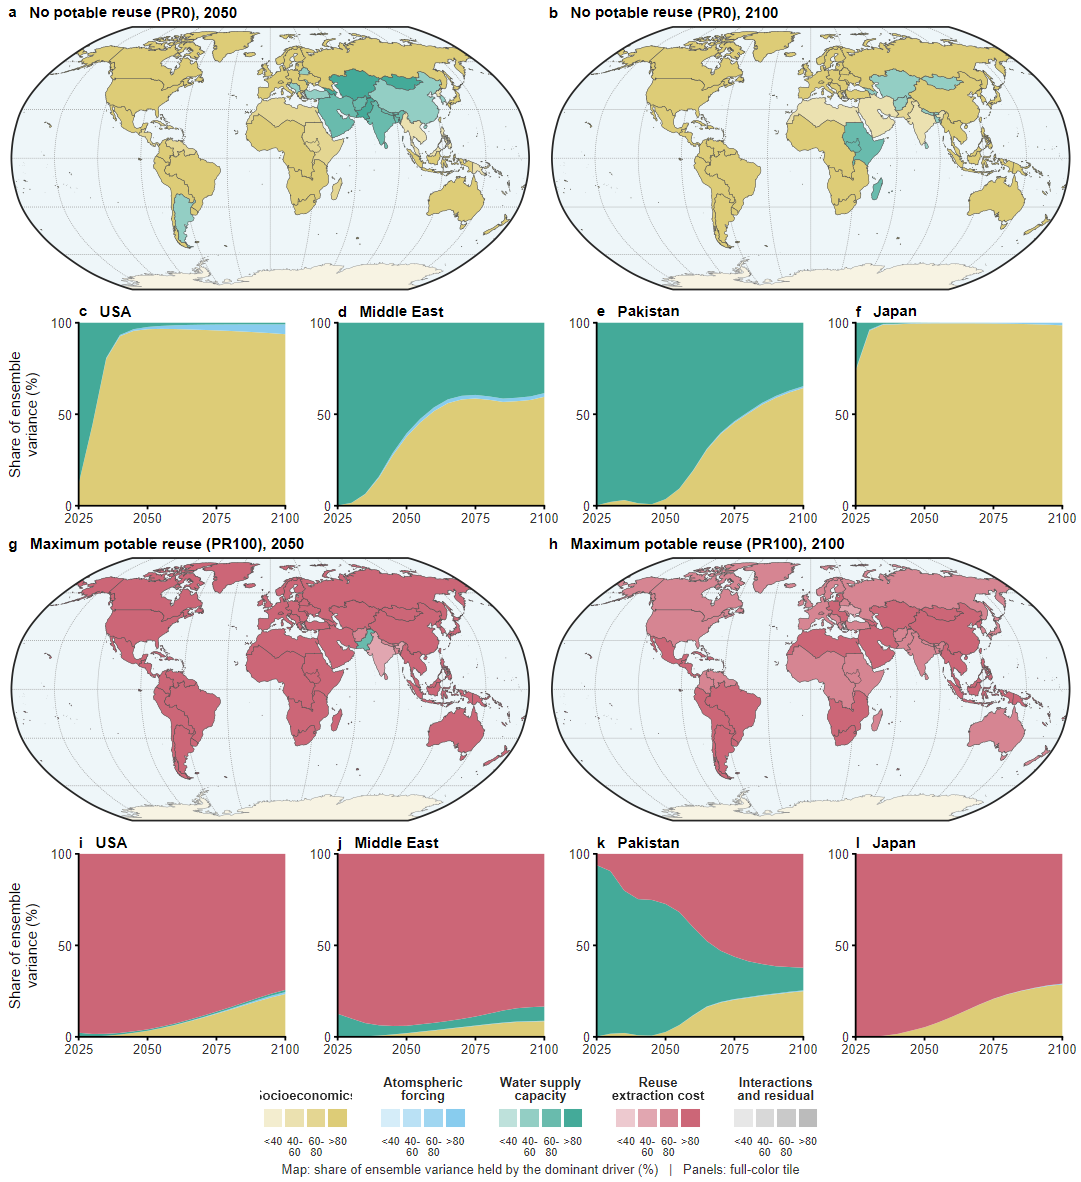

In [34]:
# =============================================================================
# Robinson projection, 2050 vs 2100, maps in a 2 x 2 grid
#     Run after sections 1-9. Same `shares` table and palette as the main
#     figure, so maps and panels still agree (checked at the end).
#     Layout:  a b   no potable reuse, 2050 | 2100
#              c-f   its four exemplar regions
#              g h   full potable reuse, 2050 | 2100
#              i-l   its four exemplar regions
#              legend
# =============================================================================
ROB_YEARS      <- c(2050L, 2100L)       # map columns
ROB_PR         <- c("PR0", "PR100")     # map rows and panel rows
ROB_FULL_GLOBE <- TRUE                  # FALSE crops at 60 S (drops Antarctica, saves height)
ROB_CRS        <- "+proj=robin +lon_0=0 +datum=WGS84 +units=m +no_defs"
OCEAN_FILL     <- "#EEF6F9"             # very pale blue, lighter than the palest rcp tint
LAND_FILL      <- "#F7F3E3"             # land outside the GCAM regions (Antarctica); cream,
                                        # not grey, so it cannot be read as the grey driver class


# ---- dominant class for the map years (same rule as `dom`) -------------------
dom_rob <- shares |>
  filter(pr %in% ROB_PR, year %in% ROB_YEARS) |>
  arrange(pr, region, year, desc(share)) |>
  group_by(pr, region, year) |>
  summarise(dominant        = as.character(first(class)),
            dominant_share  = first(share),
            runner_up       = as.character(nth(class, 2)),
            runner_up_share = nth(share, 2),
            .groups = "drop") |>
  mutate(margin    = dominant_share - runner_up_share,
         share_bin = cut(dominant_share, SHARE_BREAKS, SHARE_LABELS,
                         include.lowest = TRUE, right = FALSE),
         fill_key  = paste(dominant, share_bin, sep = "|"),
         subRegion = dplyr::recode(region, !!!NAME_CROSSWALK))
stopifnot(all(ROB_YEARS %in% dom_rob$year))

# ---- Robinson geometry: globe outline, graticule, regions ---------------------
lat_min <- if (ROB_FULL_GLOBE) -90 else -60
edge    <- rbind(cbind(seq(-180, 180, 0.5), lat_min),
                 cbind(180, seq(lat_min, 90, 0.5)),
                 cbind(seq(180, -180, -0.5), 90),
                 cbind(-180, seq(90, lat_min, -0.5)))
ROB_GLOBE <- st_sfc(st_polygon(list(edge)), crs = 4326) |> st_transform(ROB_CRS)
ROB_GRAT  <- st_graticule(c(-180, lat_min, 180, 90), crs = st_crs(4326),
                          lon = seq(-180, 180, 30), lat = seq(-60, 60, 30),
                          ndiscr = 200) |> st_transform(ROB_CRS)
ROB_REG   <- st_transform(MAP_REG,  ROB_CRS)
ROB_CTRY  <- st_transform(MAP_CTRY, ROB_CRS)
ROB_GAP   <- st_transform(gap_geom_sf, ROB_CRS)


ROB_ANT <- ROB_CTRY[0, ]
if (ROB_FULL_GLOBE && requireNamespace("rnaturalearth", quietly = TRUE)) {
  ROB_ANT <- tryCatch(
    rnaturalearth::ne_countries(scale = "medium", returnclass = "sf") |>
      filter(name == "Antarctica") |> select(geometry) |>
      st_transform(ROB_CRS) |> st_make_valid(),
    error = function(e) { message("[INFO] Antarctica not added: ", conditionMessage(e)); ROB_CTRY[0, ] })
}
ROB_BBOX  <- st_bbox(ROB_GLOBE)
ROB_ASPECT <- as.numeric((ROB_BBOX["ymax"] - ROB_BBOX["ymin"]) /
                         (ROB_BBOX["xmax"] - ROB_BBOX["xmin"]))
pad       <- 0.006 * (ROB_BBOX["xmax"] - ROB_BBOX["xmin"])   # keeps the outline from being clipped
ROB_XLIM  <- as.numeric(ROB_BBOX[c("xmin", "xmax")]) + c(-pad, pad)
ROB_YLIM  <- as.numeric(ROB_BBOX[c("ymin", "ymax")]) + c(-pad, pad)
# map height follows from its width, so there is no white space between rows
H_RMAP    <- (FIG_W_IN / length(ROB_YEARS) - 8 / 72) * ROB_ASPECT + 0.22

rob_map <- function(pr, yr, letter) {
  d      <- filter(dom_rob, pr == !!pr, year == yr)
  reg_sf <- ROB_REG |> select(subRegion, geometry) |>
    left_join(select(d, subRegion, fill_key), by = "subRegion")
  gap_sf <- left_join(ROB_GAP, select(d, subRegion, fill_key), by = "subRegion")
  ggplot() +
    geom_sf(data = ROB_GLOBE, fill = OCEAN_FILL, color = NA) +
    geom_sf(data = ROB_GRAT, color = "grey60", linewidth = 0.12, linetype = "11") +
    geom_sf(data = ROB_CTRY, fill = LAND_FILL, color = "grey45", linewidth = 0.06) +
    geom_sf(data = ROB_ANT,  fill = LAND_FILL, color = "grey45", linewidth = 0.06) +
    geom_sf(data = reg_sf, aes(fill = fill_key), color = "grey30", linewidth = 0.08) +
    geom_sf(data = gap_sf, aes(fill = fill_key), color = "grey30", linewidth = 0.08) +
    (if (OUTLINE_FOCUS) geom_sf(data = filter(reg_sf, subRegion %in% FOCUS_REGIONS),
                                fill = NA, color = "black", linewidth = 0.35) else NULL) +
    geom_sf(data = ROB_GLOBE, fill = NA, color = "grey15", linewidth = 0.3) +
    scale_fill_manual(values = FILL_PALETTE, na.value = "grey88", guide = "none") +
    coord_sf(crs = ROB_CRS, datum = NA, expand = FALSE,
             xlim = ROB_XLIM, ylim = ROB_YLIM) +
    labs(title = sprintf("%s   %s, %d", letter, PR_DESCRIPTION[[pr]], yr)) +
    theme_void(base_size = BASE_PT) +
    theme(plot.title = element_text(size = BASE_PT, face = "bold", hjust = 0,
                                    margin = margin(b = 2)),
          plot.title.position = "plot",
          plot.background = element_rect(fill = "white", color = NA),
          plot.margin     = margin(2, 4, 2, 4))
}


# ---- assemble: map pair, its 4 panels, map pair, its 4 panels, legend ----------
environment(letters_iter)$i <- 0
blocks <- list(); heights <- c(); map_pairs <- list(); rows <- list()
for (pr in ROB_PR) {
  pair <- arrangeGrob(grobs = lapply(ROB_YEARS, function(yr)
                        ggplotGrob(rob_map(pr, yr, letters_iter()))),
                      ncol = length(ROB_YEARS))
  row  <- build_row(pr)                      # same panels as the main figure, no 2050 line
  map_pairs[[pr]] <- pair; rows[[pr]] <- row
  blocks  <- c(blocks, list(pair, row))
  heights <- c(heights, H_RMAP, H_ROW)
}
blocks  <- c(blocks, list(ggplotGrob(build_legend())))
heights <- c(heights, H_LEGEND)
FIG_H_R <- sum(heights)
composite_rob <- arrangeGrob(grobs = blocks, ncol = 1, heights = unit(heights, "in"))

cat(sprintf("Canvas: %.0f x %.0f mm | map aspect (h/w) %.2f\n",
            FIG_W_IN * 25.4, FIG_H_R * 25.4, ROB_ASPECT))
base <- sprintf("figure3_composite_robinson_%s", paste(ROB_YEARS, collapse = "_"))
save_all_formats(composite_rob, file.path(FIG_DIR, base), FIG_W_IN, FIG_H_R)
for (pr in ROB_PR) {
  save_all_formats(map_pairs[[pr]], file.path(PART_DIR, paste0("maps_", pr)),
                   FIG_W_IN, H_RMAP)
  save_all_formats(rows[[pr]], file.path(PART_DIR, paste0("panels_", pr)),
                   FIG_W_IN, H_ROW)
}
save_all_formats(build_legend(), file.path(PART_DIR, "legend"), FIG_W_IN, H_LEGEND)

options(repr.plot.width = FIG_W_IN, repr.plot.height = FIG_H_R, repr.plot.res = 150)
grid.newpage(); grid.draw(composite_rob)

# ---- source data, consistency check, and the reviewer's question --------------
write.csv(dom_rob |> select(pr, year, region, dominant, dominant_share, runner_up,
                            runner_up_share, margin, share_bin) |> arrange(pr, year, region),
          file.path(TAB_DIR, "map_dominant_class_robinson.csv"), row.names = FALSE)

check_rob <- shares |>
  filter(pr %in% ROB_PR, year %in% ROB_YEARS, region %in% FOCUS_REGIONS) |>
  group_by(pr, region, year) |>
  summarise(tallest_band = as.character(class[which.max(share)]), .groups = "drop") |>
  left_join(select(dom_rob, pr, region, year, map_class = dominant),
            by = c("pr", "region", "year"))
stopifnot(all(check_rob$tallest_band == check_rob$map_class))
# cat("Map colors and panel bands agree for all focus regions in",
#     paste(ROB_YEARS, collapse = " and "), "\n\n")

# Does the map change between the two years? (answers the reviewer directly)
y1 <- min(ROB_YEARS); y2 <- max(ROB_YEARS)
change <- dom_rob |>
  select(pr, region, year, dominant, share_bin) |>
  tidyr::pivot_wider(names_from = year, values_from = c(dominant, share_bin)) |>
  mutate(driver_changed = .data[[paste0("dominant_", y1)]] != .data[[paste0("dominant_", y2)]],
         shade_changed  = .data[[paste0("share_bin_", y1)]] != .data[[paste0("share_bin_", y2)]])
print(change |> group_by(pr) |>
        summarise(regions = n(),
                  dominant_driver_changed = sum(driver_changed),
                  same_driver_other_shade = sum(!driver_changed & shade_changed),
                  identical = sum(!driver_changed & !shade_changed)) |> as.data.frame())
write.csv(change, file.path(TAB_DIR,
                            sprintf("map_change_%d_vs_%d.csv", y1, y2)), row.names = FALSE)